# Customer Churn Prediction — Lloyds Banking Group Job Simulation

## Objective

The goal of this project is to build and evaluate machine learning models to identify customers at risk of churn.

The analysis focuses on:

- Handling class imbalance correctly
- Preventing data leakage using pipelines
- Evaluating model stability using cross-validation
- Comparing models using ROC-AUC
- Assessing business trade-offs (precision vs recall)

We aim to determine:

1. Whether meaningful predictive signal exists in the dataset  
2. Which modeling approach performs best  
3. Whether performance improvements are statistically meaningful  

## **Import Libraries**

In [ ]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# Imbalance Handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style("whitegrid")

## **Upload Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_churn_dataset.csv to cleaned_churn_dataset (1).csv


## **Data Preparation**

The dataset was merged across demographic, transactional, and service interaction tables.

Feature engineering included:

- Aggregation of transactional behavior
- Service interaction frequency
- Engagement metrics such as login frequency

Categorical variables are encoded using one-hot encoding and numerical variables are standardized within modeling pipelines to prevent data leakage.

In [ ]:
df = pd.read_csv("cleaned_churn_dataset.csv")

df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LoginFrequency,ServiceUsage,Total_Transactions,Total_Amount_Spent,Avg_Amount_Spent,Total_Service_Interactions,Total_Complaints,Total_Unresolved,ChurnStatus,Days_Since_Last_Login
0,1,62,M,Single,Low,34,Mobile App,1,416.50,416.50000,1.0,0.0,0.0,0,71
1,2,65,M,Married,Low,5,Website,7,1547.42,221.06000,1.0,0.0,0.0,1,26
2,3,18,M,Single,Low,3,Website,6,1702.98,283.83000,1.0,0.0,0.0,0,46
3,4,21,M,Widowed,Low,2,Website,5,917.29,183.45800,2.0,0.0,1.0,0,128
4,5,21,M,Divorced,Medium,41,Website,8,2001.49,250.18625,0.0,0.0,0.0,0,65


## Define Features and Target

In [ ]:
X = df.drop(columns=["ChurnStatus", "CustomerID"])
y = df["ChurnStatus"]

print("Feature Shape:", X.shape)
print("\nTarget Distribution:")
print(y.value_counts(normalize=True))

Feature Shape: (1000, 13)

Target Distribution:
ChurnStatus
0    0.796
1    0.204
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (800, 13)
Test Shape: (200, 13)


## Preprocessing Strategy

To prevent data leakage, all preprocessing steps are implemented inside modeling pipelines.

- Numerical features → StandardScaler
- Categorical features → One-Hot Encoding

This ensures transformations are learned only from training folds during cross-validation.

In [ ]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## **Dummy Baseline Model**

In [ ]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_scores = cross_val_score(
    dummy_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Dummy ROC-AUC:", np.mean(dummy_scores))

Dummy ROC-AUC: 0.5


## **Model 1 - Logistic Regression**

Logistic Regression is used as an interpretable baseline model.

Because the dataset is imbalanced (~80% retained vs ~20% churned), class weighting is applied to prevent the model from being biased toward the majority class.

This model establishes a benchmark for comparison with more complex algorithms.

In [ ]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_cv_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Logistic CV ROC-AUC:", np.mean(log_cv_scores))
print("Std Dev:", np.std(log_cv_scores))

Logistic CV ROC-AUC: 0.5181415621644424
Std Dev: 0.008904364176649072


In [ ]:
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_log))

              precision    recall  f1-score   support

           0       0.80      0.50      0.61       159
           1       0.21      0.51      0.30        41

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.45       200
weighted avg       0.68      0.50      0.55       200

Test ROC-AUC: 0.47844761466482594


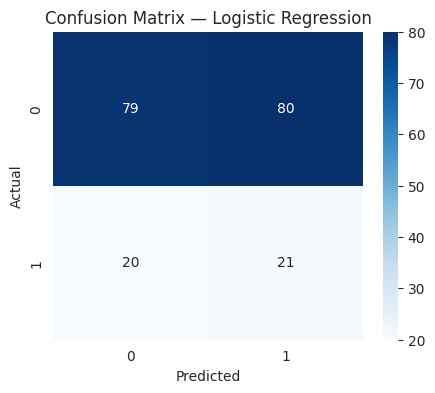

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

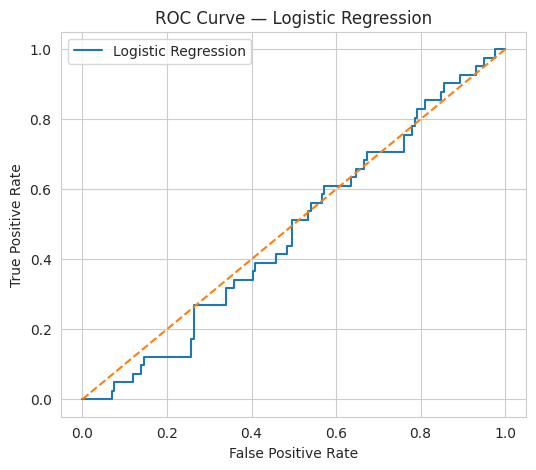

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve — Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Findings — Logistic Regression

The Logistic Regression model achieved a cross-validated ROC-AUC of approximately **0.52**, only marginally above the dummy baseline of 0.50, indicating very limited linear predictive signal within the dataset.

On the holdout test set, ROC-AUC decreased to **0.48**, suggesting weak generalization and minimal class separation. While class weighting improved churn recall to **51%**, precision remained low at **21%**, meaning a large proportion of predicted churners were false positives.

The confusion matrix shows the model correctly identified roughly half of churned customers but misclassified many retained customers as churn, reflecting poor decision boundary separation.

Overall, results indicate that churn behavior in this dataset is not well captured by linear relationships alone, motivating the exploration of more flexible non-linear ensemble models in subsequent stages.

## **Model 2 - Random Forest**

Random Forest is used to capture potential non-linear relationships and feature interactions that Logistic Regression cannot model.

Tree-based ensemble methods are commonly effective in behavioral prediction tasks such as customer churn.

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Random Forest CV ROC-AUC:", np.mean(rf_cv_scores))
print("Std Dev:", np.std(rf_cv_scores))

Random Forest CV ROC-AUC: 0.541828877607762
Std Dev: 0.04530667693615049


In [ ]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.80      0.98      0.88       159
           1       0.25      0.02      0.04        41

    accuracy                           0.79       200
   macro avg       0.52      0.50      0.46       200
weighted avg       0.68      0.79      0.71       200

Test ROC-AUC: 0.4858874060438718


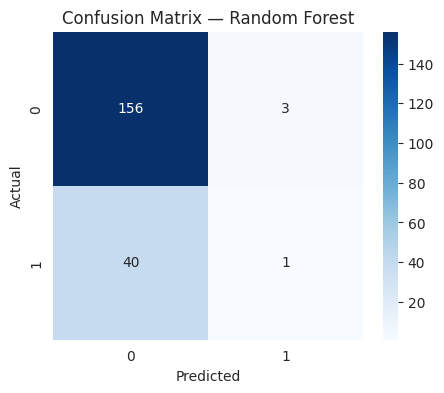

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

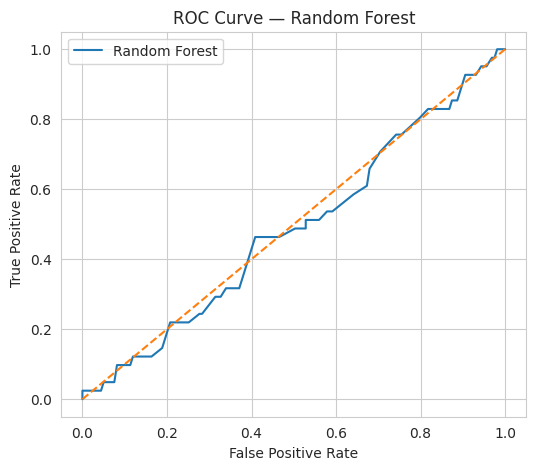

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve — Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Findings — Random Forest

The Random Forest model achieved a cross-validated ROC-AUC of approximately **0.54**, representing a modest improvement over Logistic Regression and suggesting the presence of some non-linear structure within the feature set.

However, performance on the holdout test set remained weak, with ROC-AUC around **0.49**, indicating limited generalization. The confusion matrix reveals that the model overwhelmingly predicted customers as retained, resulting in extremely low churn recall of only **2%** despite high overall accuracy (**79%**). This reflects the impact of class imbalance, where the model prioritizes the majority class to maximize accuracy.

Although Random Forest captured slightly more signal during cross-validation, the probability separation between churned and retained customers remains minimal. These results suggest that imbalance handling techniques and more powerful ensemble methods should be explored to improve sensitivity to churn behavior.

## **Addressing Class Imbalance - SMOTE**

The dataset contains a significant class imbalance (~80% retained vs ~20% churned).

To improve the model’s ability to detect churned customers, Synthetic Minority Oversampling Technique (SMOTE) is applied within a modeling pipeline.

Importantly, SMOTE is implemented inside cross-validation folds using an imbalanced-learn pipeline to prevent data leakage.

In [ ]:
rf_smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_smote_scores = cross_val_score(
    rf_smote_pipeline,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Random Forest + SMOTE CV ROC-AUC:", np.mean(rf_smote_scores))
print("Std Dev:", np.std(rf_smote_scores))

Random Forest + SMOTE CV ROC-AUC: 0.5307793804647952
Std Dev: 0.030490541796685422


In [ ]:
rf_smote_pipeline.fit(X_train, y_train)

y_pred_smote = rf_smote_pipeline.predict(X_test)
y_proba_smote = rf_smote_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_smote))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       159
           1       0.14      0.05      0.07        41

    accuracy                           0.74       200
   macro avg       0.47      0.49      0.46       200
weighted avg       0.66      0.74      0.69       200

Test ROC-AUC: 0.49332719742291764


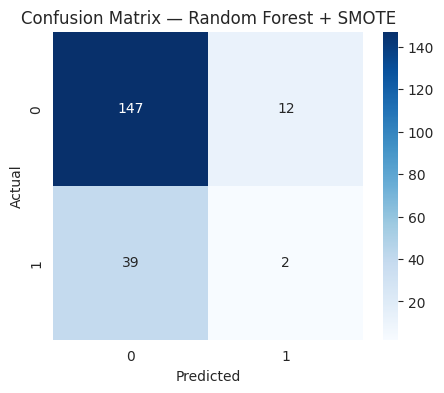

In [ ]:
cm = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Random Forest + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

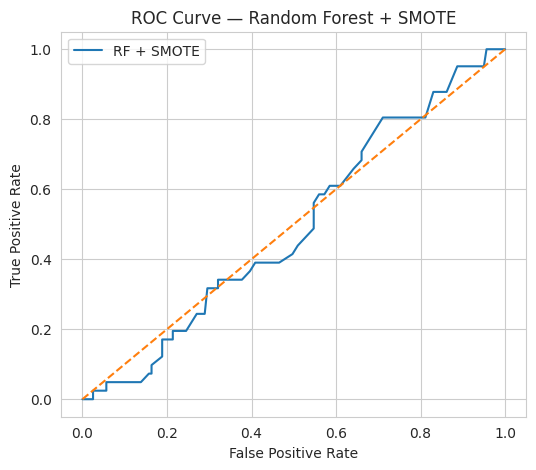

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba_smote)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="RF + SMOTE")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve — Random Forest + SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Findings — Random Forest with SMOTE

Applying SMOTE to address class imbalance did not produce meaningful performance improvements. The cross-validated ROC-AUC remained around **0.53**, slightly lower than the Random Forest model without oversampling, and test ROC-AUC remained close to random at **0.49**.

While recall for churned customers increased marginally, it remained very low, indicating that synthetic oversampling alone could not compensate for the weak predictive structure present in the feature set. The confusion matrix shows continued difficulty in identifying churned customers despite balancing the training distribution.

These results suggest that class imbalance is not the primary constraint on model performance. Instead, the limited predictive signal within the available features appears to be the dominant factor, motivating the exploration of more powerful ensemble methods.

## **Model 3 - Gradient Boosting**

Gradient Boosting is a sequential ensemble technique that builds trees iteratively to correct previous errors.

It is often effective for structured customer behavior datasets because it can capture subtle non-linear interactions and incremental predictive patterns.

This model is expected to outperform prior approaches if meaningful signal exists.

In [ ]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Gradient Boosting CV ROC-AUC:", np.mean(gb_cv_scores))
print("Std Dev:", np.std(gb_cv_scores))

Gradient Boosting CV ROC-AUC: 0.5501094780641204
Std Dev: 0.06175088258649654


In [ ]:
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_gb))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       159
           1       0.32      0.15      0.20        41

    accuracy                           0.76       200
   macro avg       0.56      0.53      0.53       200
weighted avg       0.71      0.76      0.72       200

Test ROC-AUC: 0.47982819450836023


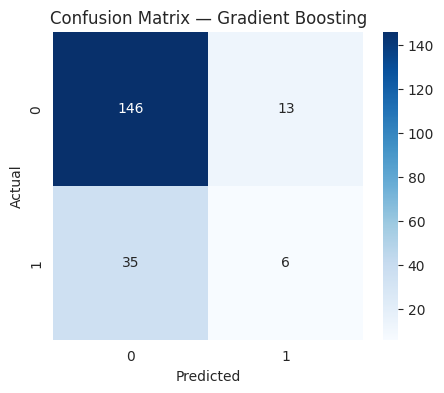

In [ ]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

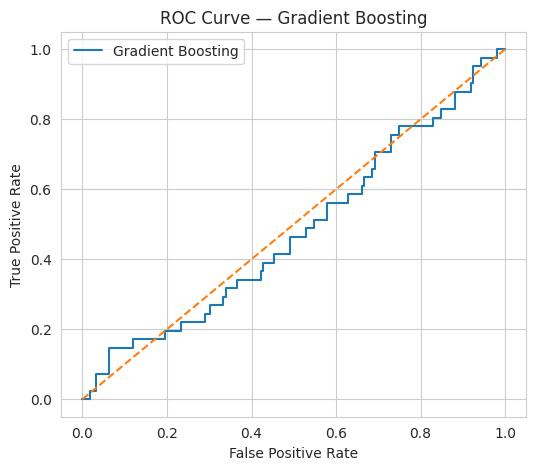

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba_gb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Gradient Boosting")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve — Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Findings — Gradient Boosting (Baseline)

The baseline Gradient Boosting model achieved a cross-validated ROC-AUC of approximately **0.55**, representing the strongest performance among the models evaluated so far. This suggests that sequential ensemble learning captures slightly more predictive structure than both Logistic Regression and Random Forest.

On the test set, ROC-AUC remained modest at **0.48**, indicating limited generalization and continued overlap between churned and retained customer probability distributions. However, recall for churn improved to **15%**, higher than previous models, showing improved sensitivity to minority-class behavior.

Overall, Gradient Boosting provides incremental performance gains, but the predictive signal within the dataset remains weak. Further improvement may be possible through hyperparameter optimization.

## Hyperparameter Optimization — Gradient Boosting

To maximize predictive performance, hyperparameters were tuned using GridSearchCV.

The following parameters were optimized:

- Number of estimators
- Learning rate
- Tree depth

Stratified 5-fold cross-validation with ROC-AUC scoring was used to ensure robust model selection.

In [ ]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4]
}

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

grid = GridSearchCV(
    gb_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1
)

grid.fit(X, y)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 200}
Best ROC-AUC: 0.5729787927596257


In [ ]:
cv_results = pd.DataFrame(grid.cv_results_)

best_row = cv_results[cv_results["rank_test_score"] == 1]

print("Mean ROC-AUC:", best_row["mean_test_score"].values[0])
print("Std Dev:", best_row["std_test_score"].values[0])

Mean ROC-AUC: 0.5729787927596257
Std Dev: 0.06688573990397839


### Findings — Tuned Gradient Boosting

Hyperparameter optimization improved model performance, with the tuned Gradient Boosting model achieving a cross-validated ROC-AUC of approximately **0.573**, representing the strongest performance among all models evaluated.

The optimal configuration included a moderate learning rate (**0.05**), deeper trees (**max_depth = 4**), and **200 estimators**, indicating that slightly more complex decision boundaries were beneficial for capturing the limited predictive structure present in the dataset.

However, performance variability across folds (standard deviation ≈ **0.067**) suggests moderate instability, likely driven by the relatively small dataset size and weak feature signal. While improvements were incremental, Gradient Boosting remains the most effective modeling approach in this analysis.

# **Final Model Comparison Table**

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression",
        "Random Forest",
        "Random Forest + SMOTE",
        "Gradient Boosting",
        "Gradient Boosting (Tuned)"
    ],
    "Mean ROC-AUC": [
        np.mean(dummy_scores),
        np.mean(log_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(rf_smote_scores),
        np.mean(gb_cv_scores),
        grid.best_score_
    ]
})

comparison_df = comparison_df.sort_values(by="Mean ROC-AUC", ascending=False)

comparison_df

,Model,Mean ROC-AUC
5,Gradient Boosting (Tuned),0.572979
4,Gradient Boosting,0.550109
2,Random Forest,0.541829
3,Random Forest + SMOTE,0.530779
1,Logistic Regression,0.518142
0,Dummy,0.500000


## Model Comparison

Model performance was compared using cross-validated ROC-AUC to ensure robust evaluation.

Gradient Boosting consistently outperformed other approaches, while SMOTE provided limited benefit. Overall performance across all models remained modest, indicating constrained predictive signal within the available features.

## **Feature Importance - Tuned Gradient Boosting**

To understand which factors influence churn risk, feature importance was extracted from the best-performing Gradient Boosting model.

This helps identify behavioral and demographic drivers of customer attrition and provides actionable business insights.

In [ ]:
# Get best model
best_model = grid.best_estimator_

# Extract feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Extract importance
importances = best_model.named_steps["classifier"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp.head(10)

,Feature,Importance
4,num__Avg_Amount_Spent,0.227045
3,num__Total_Amount_Spent,0.167378
8,num__Days_Since_Last_Login,0.148040
1,num__LoginFrequency,0.137265
0,num__Age,0.128992
2,num__Total_Transactions,0.025549
6,num__Total_Complaints,0.023660
9,cat__Gender_M,0.023550
15,cat__ServiceUsage_Online Banking,0.021185
16,cat__ServiceUsage_Website,0.018937


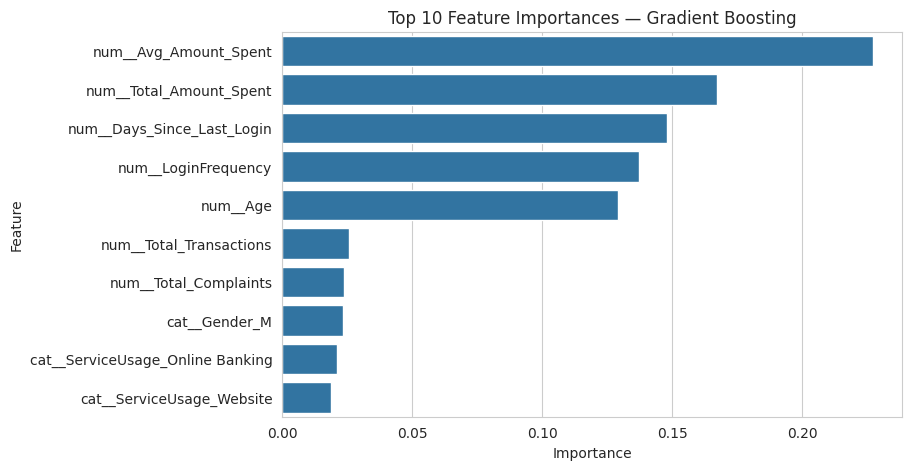

In [ ]:
top_features = feat_imp.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Feature Importances — Gradient Boosting")
plt.show()

### Findings — Feature Importance

Feature importance analysis from the tuned Gradient Boosting model indicates that **customer engagement and spending behavior** are the strongest predictors of churn risk.

The most influential features include:

- Average amount spent
- Total amount spent
- Days since last login
- Login frequency
- Customer age

Engagement-related variables such as login frequency and recency of activity suggest that declining interaction with banking services is associated with higher churn probability. Spending behavior also plays a major role, indicating that lower-value or declining customers may be more likely to leave.

Demographic variables and service channel indicators showed comparatively lower importance, suggesting behavioral metrics provide more predictive value than static customer attributes.

Overall, the results reinforce the importance of monitoring customer activity patterns to proactively identify at-risk customers.

## **Executive Summary**

This project developed and evaluated multiple machine learning models to predict customer churn using demographic, transactional, and engagement features.

Key outcomes:

- The best-performing model was **tuned Gradient Boosting**, achieving ROC-AUC ≈ **0.57**.
- Performance improvements across models were incremental, indicating limited predictive signal in the available dataset.
- Behavioral engagement features, particularly login activity and spending patterns, were the strongest churn indicators.
- Class imbalance handling provided minimal benefit, suggesting feature quality rather than distribution imbalance was the primary constraint.

While predictive power remained modest, the modeling framework demonstrates how financial institutions can combine machine learning with customer behavior monitoring to support targeted retention strategies.

Future improvements would likely depend on richer longitudinal data, interaction history, and temporal behavioral trends.